# Use examples of [edges_AWAREincremental](https://github.com/GeAaSe/edges_AWAREinc)

Main Author of edges: [romainsacchi](https://github.com/romainsacchi) 

Author of this version: [Georg Seitfudem](https://github.com/geaase)

This notebook shows examples on how to use `edges_AWAREincremental` to implement incremental LCIA with AWARE2.0.

## Requirements
* **Pyhton 3.10 or higher (up to 3.11) is highly recommended**
* **ecoinvent 3.10 or 3.11**
* **a brightway2 or brightway2.5 installation**

### Note
> This is a proof-of concept, there is no aspiration to make it a shippable tool separately from edges. Some features may become integrated into the main edges project later on. Caveats for now:
>- redo_lcia is not adjusted for compliance with incremental method. If you would like to rerun the LCA, it needs to be done via rerunning the standard workflow.
>- stochastic approaches do not work with the incremental method (also, there is no uncertainty information for the incremental CFs). 

In [ ]:
from edges import EdgeLCIA, get_available_methods, setup_package_logging
import bw2data
import matplotlib.pyplot as plt
# in case logging is desired:
setup_package_logging(level=10)

In [2]:
bw2data.projects.set_current("edges_AWAREinc_ei3101")

*edges* provides several versions of AWARE2.0, with the original watershed, monthly CFs aggregated to country or province level. With *edges_AWAREincremental*, an additional AWARE2.0 version is added, called AWARE2.0 incremental. This version combines two concepts:
1. The country level CFs or unspecified (unknown) water use sectors. These weight different watersheds and months by the overall spatiotemporal water consumption patterns
2. The basin level CFs in monthly resolution. However, the method does not *contain* the CFs. Instead, it refers to a function that calculates the CFs at runtime, as incremental CFs based on the LCA inventory.

In [3]:
[x for x in get_available_methods() if "AWARE 2.0" in x] # by displaying their names, the methods are not yet loaded into memory

[('AWARE 2.0', 'Country', 'all', 'yearly'),
 ('AWARE 2.0', 'Country', 'irri', 'yearly'),
 ('AWARE 2.0', 'Country', 'non', 'irri', 'yearly'),
 ('AWARE 2.0', 'Country', 'unspecified', 'yearly'),
 ('AWARE 2.0', 'incremental')]

To be able to use the method, the *plugin_methods* module is required. It contains class that is used to represent watersheds, calculate the current impact and the impact slope.

In [4]:
# load functions required for incremental AWARE CF calculation 
from edges.plugin_methods import load_AWARE_basin_data
basin_topologies, BASIN_MEMORY = load_AWARE_basin_data()

def calculate_CF(basin_id, inventory, settings,*, seasonality = "annual"):
    """
    calculates CFs based on the AWARE method's analytical model of an impact curve.
    inventory: positive or negative scalar of water consumption elementary flow. 
    settings: dictionary that includes a boolean for the key "included_in_background"
    seasonality: needs to be a string ('annual' or 'Jan', 'Feb',...). If different months together, they need to be separated by underscores.
    This is to circumvent the interpretation as scenarios for lists and tuples in the safe_eval() 
    """  
    # if included in background, slope needs to be calculated towards the left, 
    # but cf needs to be positive, so cf sign is changed
    inv = inventory
    if settings["included_in_background"]: inv = -inv
    seasonality = seasonality.split("_")
    BASIN_MEMORY.add_seasonal(basin_id, inv, seasonality)
    cf = BASIN_MEMORY.incremental_CF_seasonal(basin_id, seasonality)
    return cf


The calculate_CF() function takes arguments required to calculate an incremental CF. All actual calculations are performed in the BASIN_MEMORY.

In [5]:
BASIN_MEMORY

<BasinMemory
month-basin-combinations=112872
cf calculation iterations=0
number of touched MBCs=0>

This is how to calculate incremental CFs:

CF calculation rounds
1st: 1.0351 
2nd: 1.0601

--history of total water consumption in watershed--
April: [809526.0, 5809526.0, 10809526.0, 9309526.0, 34309526.0]
May:   [2513827.0, 7513827.0, 12513827.0, 11013827.0, 36013827.0]

--CFs calculated for the two months individually--
April: [0.8191417878198679, 0.8339677315070446, 0.8294447498240829, 0.91477366959997]
May:   [1.2510659143468725, 1.2863274123843174, 1.2754703340807265, 1.4974069474339569]
removed last 0 positions


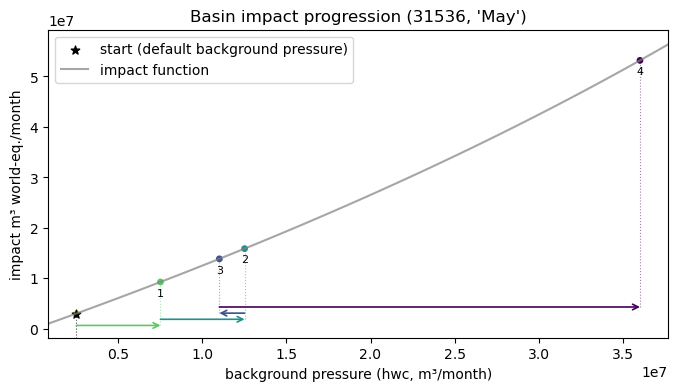

In [6]:
BASIN_MEMORY.reset()
# we can calculate the CF for an addition of 10^7 m3 water consumption in basin 31536
first = calculate_CF(31536, 1e7, {"included_in_background":False}, seasonality = "_".join(["Apr", "May"]))

# if we do it again (adding 1e7 m3), the value changes, because now we added 2e7 m3 in total.
second = calculate_CF(31536, 1e7, {"included_in_background":False}, seasonality = "_".join(["Apr", "May"]))

# if we do it again (adding 1e7 m3), the value changes, because now we added 2e7 m3 in total.
third = calculate_CF(31536, -0.3e7, {"included_in_background":False}, seasonality = "_".join(["Apr", "May"]))

# if we do it again (adding 1e7 m3), the value changes, because now we added 2e7 m3 in total.
third = calculate_CF(31536, 5e7, {"included_in_background":False}, seasonality = "_".join(["Apr", "May"]))

# and the CF is always calculated from the default background pressure assumed in regular AWARE2.0 to the new background pressure
print("CF calculation rounds")
print("1st:",round(first,4), "\n2nd:", round(second,4))

# we can check how the total water consumption evolved in the watershed:
print("\n--history of total water consumption in watershed--\nApril:", BASIN_MEMORY.get_increments(31536,"Apr"))
print("May:  ", BASIN_MEMORY.get_increments(31536,"May"))

# we can also check the CFs that were calculated for the two months individually. The CFs we calculated above were averages of these.
print("\n--CFs calculated for the two months individually--\nApril:", BASIN_MEMORY.get_increm_cfs((31536,"Apr")))
print("May:  ", BASIN_MEMORY.get_increm_cfs((31536,"May")))

# we can plot the overall progression on the impact curve
BASIN_MEMORY.plot_impact_progress((31536,"May"))

# to not mess up the actual LCIA calculation later, we reset ALL basins and months
BASIN_MEMORY.reset()

### Calculating the LCA
By default, ecoinvent contains no processes that are regionalized on basin level. We take a wheat grain production process from Spain and make it specific for the Ebro watershed (Basin_ID: 32963).

In [7]:
ebro_basin = "B32963"

db = bw2data.Database("ecoinvent-3.10.1-cutoff")
spanish_wheat = db.search("wheat grain production", filter={"location": "ES"})[0]
# Reuse the activity if it was already created earlier
existing = [a for a in db if a["name"] == "wheat grain production" and a["location"] == ebro_basin]
assert len(existing)==1

if existing:
    ebro_wheat = existing[0]
else:
    ebro_wheat = spanish_wheat.copy()
    ebro_wheat["location"] = ebro_basin # basin locations are called 'B<Basin_ID>'
    ebro_wheat.save()

# these are the three water flows of the process, the non-air flows are characterized in AWARE
print("water exchanges of", ebro_wheat)
[print(x) for x in ebro_wheat.biosphere() if "Water" in x["name"]]
# this is the irrigation flow that has to be regionalized as well:
irri = [x for x in ebro_wheat.technosphere() if "irr" in x["name"]][0]
print("irrigation: ", irri)

Excluding 53 filtered results
water exchanges of 'wheat grain production' (kilogram, B32963, None)
Exchange: 0.503061806011495 cubic meter 'Water' (cubic meter, None, ('air',)) to 'wheat grain production' (kilogram, B32963, None)>
Exchange: 0.168481814673278 cubic meter 'Water' (cubic meter, None, ('water', 'ground-')) to 'wheat grain production' (kilogram, B32963, None)>
Exchange: 0.0421204536683195 cubic meter 'Water' (cubic meter, None, ('water', 'surface water')) to 'wheat grain production' (kilogram, B32963, None)>
irrigation:  Exchange: 0.713664074353092 cubic meter 'irrigation, sprinkler' (cubic meter, B32963, None) to 'wheat grain production' (kilogram, B32963, None)>


generate regionalized sprinkler acticity if not existing

In [8]:
existing = [a for a in db if a["name"] == "irrigation, sprinkler" and a["location"] == ebro_basin]
assert len(existing)==1
if existing:
    ebro_sprinkler = existing[0]
else:
    spanish_sprinkler = db.search("irrigation, sprinkler", filter={"location": "ES"})[0]
    ebro_sprinkler = spanish_sprinkler.copy()
    ebro_sprinkler["location"] = ebro_basin
    ebro_sprinkler.save()

irri.input = ebro_sprinkler
irri.save()

however, regionalization is not enough. We assume the wheat was irrigated from April to June. Therefore, we adjust both involved activities to these months.

In [9]:
for act in [ebro_wheat,ebro_sprinkler]:
    act["ConsumerSeason"] = "_".join(["Apr","May", "Jun"])
    act.save()
ebro_wheat.as_dict()

{'comment': 'Geography:  Refers to an average production in the region Castilla-y-Leon (ES).\nTechnology:  conventional production typical for the region\nTime period:  The yield data have been collected for the years 2000-2004.',
 'classifications': [('ISIC rev.4 ecoinvent',
   '0111:Growing of cereals (except rice), leguminous crops and oil seeds'),
  ('CPC', '01112: Wheat, other')],
 'activity type': 'ordinary transforming activity',
 'activity': 'a2cb1a58-5ef4-5949-bb94-a2e90eb2aafe',
 'database': 'ecoinvent-3.10.1-cutoff',
 'filename': 'a2cb1a58-5ef4-5949-bb94-a2e90eb2aafe_0201ee86-f71b-4457-8fe8-79f3ed720b07.spold',
 'location': 'B32963',
 'name': 'wheat grain production',
 'synonyms': ['Triticum aestivum L.'],
 'parameters': [{'description': 'fraction, irrigation water to surface water',
   'id': '1fc3aad5-5775-4890-b32b-7d940b66bd3c',
   'unit': 'dimensionless',
   'comment': 'Literature value (Döll, 2011) cross referenced with expert opinion.',
   'amount': 0.2,
   'pedigree':

the irrigation edge provides the irrigation service from the Ebro watershed:

In [10]:
[x for x in ebro_wheat.technosphere()]

[Exchange: 0.0751474708532345 kilogram 'market for ammonium nitrate' (kilogram, RER, None) to 'wheat grain production' (kilogram, B32963, None)>,
 Exchange: 0.00032793 hectare 'market for application of plant protection product, by field sprayer' (hectare, GLO, None) to 'wheat grain production' (kilogram, B32963, None)>,
 Exchange: 0.00032793 hectare 'market for combine harvesting' (hectare, GLO, None) to 'wheat grain production' (kilogram, B32963, None)>,
 Exchange: 0.00065587 hectare 'market for fertilising, by broadcaster' (hectare, GLO, None) to 'wheat grain production' (kilogram, B32963, None)>,
 Exchange: 0.0236 kilogram 'market for inorganic phosphorus fertiliser, as P2O5' (kilogram, ES, None) to 'wheat grain production' (kilogram, B32963, None)>,
 Exchange: 0.713664074353092 cubic meter 'irrigation, sprinkler' (cubic meter, B32963, None) to 'wheat grain production' (kilogram, B32963, None)>,
 Exchange: 0.11554 kilogram 'market for packaging, for fertilisers' (kilogram, GLO, Non

Do a standard LCA with country CFs. Basins are not yet respected, so we expect that the irrigation flow is resolved to the next larger geometry.

In [11]:
LCA = EdgeLCIA(
    demand={ebro_wheat: 1},
    method=('AWARE 2.0', 'Country', 'all', 'yearly')
)
LCA.lci()
LCA.apply_strategies()
LCA.evaluate_cfs()
LCA.lcia()
print("Final score:", LCA.score)
cf_df = LCA.generate_cf_table()

Finding direct matches        [1/5]
Resolving aggregate locations [2/5]
Resolving dynamic locations   [3/5]
{'BR-RR': [], 'Europe without Austria': ['AD', 'AL', 'BA', 'BE', 'BG', 'BY', 'CH', 'CZ', 'DE', 'DK', 'EE', 'FI', 'FR', 'GB', 'GI', 'GR', 'HR', 'HU', 'IE', 'IM', 'IS', 'IT', 'JE', 'LI', 'LT', 'LU', 'LV', 'MC', 'MD', 'ME', 'MK', 'MT', 'NL', 'NO', 'PL', 'PT', 'RO', 'RS', 'SE', 'SI', 'SK', 'SM', 'UA'], 'SAS': ['AF', 'BD', 'BT', 'IN-AP', 'IN-AR', 'IN-AS', 'IN-BR', 'IN-CH', 'IN-CT', 'IN-DH', 'IN-DL', 'IN-GA', 'IN-GJ', 'IN-HP', 'IN-HR', 'IN-JH', 'IN-JK', 'IN-KA', 'IN-KL', 'IN-MH', 'IN-ML', 'IN-MN', 'IN-MP', 'IN-MZ', 'IN-NL', 'IN-OR', 'IN-PB', 'IN-PY', 'IN-RJ', 'IN-SK', 'IN-TN', 'IN-TR', 'IN-UP', 'IN-UT', 'IN-WB', 'IR', 'LK', 'NP', 'PK'], 'US-WECC': ['US-CA', 'US-CO', 'US-ID', 'US-OR', 'US-WA'], 'IN-WB': [], 'CH': [], 'CA-AB': [], 'US-OR': [], 'IN-JH': [], 'IN-GJ': [], 'MX': [], 'IN-RJ': [], 'CN-GD': [], 'QA': [], 'CN-SC': [], 'DO': [], 'US-MRO': ['US-IA', 'US-MN', 'US-ND'], 'IN-ML': [],

We see that in this run the global CF for irrigation activities (42.8) was used for our Ebro basin, because the method did not know what to do with the Basin ID. The global CF was dynamically recalculated in edges, therefore it is slightly off from the official irrigation CF of 43.1.
> Pro tip: CFs in AWARE2.0 are only provided with 3 significant figures. So anything that has more of them must have been recalculated at runtime.

In [12]:
cf_df.loc[cf_df["consumer location"] == ebro_basin]

,supplier matrix,direction,supplier name,supplier categories,consumer name,consumer reference product,consumer location,consumer cpc,consumer ecospold01categories,consumer isic rev.4 ecoinvent,amount,CF,impact
8899,biosphere,biosphere-technosphere,"Water, well, in ground","(natural resource, in water)","irrigation, sprinkler",irrigation,B32963,86119: Other support services to crop production,None,0161:Support activities for crop production,0.264833,42.83795,11.344902
8900,biosphere,biosphere-technosphere,Water,"(water, surface water)",wheat grain production,wheat grain,B32963,"01112: Wheat, other",None,"0111:Growing of cereals (except rice), legumin...",0.042120,-42.83795,-1.804354
8901,biosphere,biosphere-technosphere,Water,"(water, ground-)",wheat grain production,wheat grain,B32963,"01112: Wheat, other",None,"0111:Growing of cereals (except rice), legumin...",0.168482,-42.83795,-7.217415
8902,biosphere,biosphere-technosphere,"Water, river","(natural resource, in water)","irrigation, sprinkler",irrigation,B32963,86119: Other support services to crop production,None,0161:Support activities for crop production,0.448831,42.83795,19.227004


Now, we provide the basin topography to edges. This means that even if we do not have the CF for a basin provided (since the method is still the Country level method), at least the code knows the next-higher geography.

In [13]:
LCA = EdgeLCIA(
    demand={ebro_wheat: 1},
    method=('AWARE 2.0', 'Country', 'all', 'yearly'),
    additional_topologies = {"fine_topology": basin_topologies},
    allowed_functions={"calculate_CF":calculate_CF, "BASIN_MEMORY": BASIN_MEMORY}
)
LCA.lci()
LCA.apply_strategies()
LCA.evaluate_cfs()
LCA.lcia()
print("Final score:", LCA.score)
cf_df_1 = LCA.generate_cf_table()
print("CFs for basin:",
cf_df.loc[cf_df["consumer location"] == ebro_basin,"CF"])

Finding direct matches        [1/5]
Resolving aggregate locations [2/5]
Resolving dynamic locations   [3/5]
{'BR-RR': [], 'Europe without Austria': ['AD', 'AL', 'BA', 'BE', 'BG', 'BY', 'CH', 'CZ', 'DE', 'DK', 'EE', 'FI', 'FR', 'GB', 'GI', 'GR', 'HR', 'HU', 'IE', 'IM', 'IS', 'IT', 'JE', 'LI', 'LT', 'LU', 'LV', 'MC', 'MD', 'ME', 'MK', 'MT', 'NL', 'NO', 'PL', 'PT', 'RO', 'RS', 'SE', 'SI', 'SK', 'SM', 'UA'], 'SAS': ['AF', 'BD', 'BT', 'IN-AP', 'IN-AR', 'IN-AS', 'IN-BR', 'IN-CH', 'IN-CT', 'IN-DH', 'IN-DL', 'IN-GA', 'IN-GJ', 'IN-HP', 'IN-HR', 'IN-JH', 'IN-JK', 'IN-KA', 'IN-KL', 'IN-MH', 'IN-ML', 'IN-MN', 'IN-MP', 'IN-MZ', 'IN-NL', 'IN-OR', 'IN-PB', 'IN-PY', 'IN-RJ', 'IN-SK', 'IN-TN', 'IN-TR', 'IN-UP', 'IN-UT', 'IN-WB', 'IR', 'LK', 'NP', 'PK'], 'US-WECC': ['US-CA', 'US-CO', 'US-ID', 'US-OR', 'US-WA'], 'IN-WB': [], 'CH': [], 'CA-AB': [], 'US-OR': [], 'IN-JH': [], 'IN-GJ': [], 'MX': [], 'IN-RJ': [], 'CN-GD': [], 'QA': [], 'CN-SC': [], 'DO': [], 'US-MRO': ['US-IA', 'US-MN', 'US-ND'], 'IN-ML': [],

We see that the AWARE basin still received the global CF. The reason for that is that the Ebro basin intersects several countries, and the impact assessment method only contains country CFs. Therefore, no single match as a higher-level geography was found and a GLO situation was assumed. For non-transboundary basins the country CF would have been selected by edges, e.g. for this basin in Québec:

In [14]:
# for the ebro basin, edges (actually, the library constructive_geometries) does not find a higher level CF:
print("Ebro: B32963",LCA.geo.resolve(ebro_basin, containing=False))
# for a basin in Quebec which is entirely in Quebec, not crossing borders, edges is successful
print("basin in Quebec: B27062",LCA.geo.resolve("B27062", containing=False))

Ebro: B32963 []
basin in Quebec: B27062 ['CA-QC']


Consequently, when using AWARE basins as activity locations, we should ensure first that the impact method contains data for these basins, especially if they are transboundary. Therefore, we will now use the method with basin CFs. This takes much longer than before, since now the CFs have to be chosen from a much larger offer of CFs (>9000 instead of ~400).

# basin-month-specific incremental LCIA
To be able to meaningfully showcase the incremental approach, we use 2 Million tonnes of grain production instead of 1 kg.

In [15]:
BASIN_MEMORY.reset() # just in case we already used it before, ensures that we start at the current background pressure 
LCA = EdgeLCIA(
    demand={ebro_wheat: 2e9}, # 2000000 tonnes of wheat grain
    method=('AWARE 2.0', 'incremental'),
    additional_topologies = {"fine_topology": basin_topologies},
    allowed_functions={"calculate_CF":calculate_CF, "BASIN_MEMORY": BASIN_MEMORY}
)
LCA.lci()

In [16]:
# takes about 3 minutes on system with 32 GB RAM (matching speed seems to be RAM-limited)
LCA.apply_strategies()

Finding direct matches        [1/5]
Resolving aggregate locations [2/5]
Resolving dynamic locations   [3/5]
{'BR-RR': [], 'Europe without Austria': ['AD', 'AL', 'BA', 'BE', 'BG', 'BY', 'CH', 'CZ', 'DE', 'DK', 'EE', 'FI', 'FR', 'GB', 'GI', 'GR', 'HR', 'HU', 'IE', 'IM', 'IS', 'IT', 'JE', 'LI', 'LT', 'LU', 'LV', 'MC', 'MD', 'ME', 'MK', 'MT', 'NL', 'NO', 'PL', 'PT', 'RO', 'RS', 'SE', 'SI', 'SK', 'SM', 'UA'], 'SAS': ['AF', 'BD', 'BT', 'IN-AP', 'IN-AR', 'IN-AS', 'IN-BR', 'IN-CH', 'IN-CT', 'IN-DH', 'IN-DL', 'IN-GA', 'IN-GJ', 'IN-HP', 'IN-HR', 'IN-JH', 'IN-JK', 'IN-KA', 'IN-KL', 'IN-MH', 'IN-ML', 'IN-MN', 'IN-MP', 'IN-MZ', 'IN-NL', 'IN-OR', 'IN-PB', 'IN-PY', 'IN-RJ', 'IN-SK', 'IN-TN', 'IN-TR', 'IN-UP', 'IN-UT', 'IN-WB', 'IR', 'LK', 'NP', 'PK'], 'US-WECC': ['US-CA', 'US-CO', 'US-ID', 'US-OR', 'US-WA'], 'IN-WB': [], 'CH': [], 'CA-AB': [], 'US-OR': [], 'IN-JH': [], 'IN-GJ': [], 'MX': [], 'IN-RJ': [], 'CN-GD': [], 'QA': [], 'CN-SC': [], 'DO': [], 'US-MRO': ['US-IA', 'US-MN', 'US-ND'], 'IN-ML': [],

In [17]:
# mandatory last step
LCA.evaluate_cfs()
LCA.lcia()
cf_df_2 = LCA.generate_cf_table()
LCA.score

38201995562.06841

The water flows of the wheat grain production and upstream irrigation activity now use a new CF:
> 37.306415

This CF is the (arithmetic) average of the three months in which water is consumed

In [18]:
relevant_cols = [3,4,6,10,11,12]
cf_df_2.loc[cf_df_2["consumer location"]==ebro_basin].iloc[:,relevant_cols]

,supplier categories,consumer name,consumer location,amount,CF,impact
8899,"(water, surface water)",wheat grain production,B32963,8.424091e+07,-37.306415,-3.142726e+09
8900,"(water, ground-)",wheat grain production,B32963,3.369636e+08,-37.306415,-1.257090e+10
8901,"(natural resource, in water)","irrigation, sprinkler",B32963,5.296659e+08,37.306415,1.975994e+10
8902,"(natural resource, in water)","irrigation, sprinkler",B32963,8.976622e+08,37.306415,3.348856e+10


Of course, there are other sprinkler processes in the results which still use the marginal CFs, but with considerably lower impact:

In [19]:
cf_df_2.loc[cf_df_2["consumer name"]=="irrigation, sprinkler"].sort_values("amount", ascending=False).head(6).iloc[:,relevant_cols]

,supplier categories,consumer name,consumer location,amount,CF,impact
8902,"(natural resource, in water)","irrigation, sprinkler",B32963,8.976622e+08,37.306415,3.348856e+10
8901,"(natural resource, in water)","irrigation, sprinkler",B32963,5.296659e+08,37.306415,1.975994e+10
2062,"(natural resource, in water)","irrigation, sprinkler",US,1.655885e+06,33.700000,5.580331e+07
2833,"(natural resource, in water)","irrigation, sprinkler",US,1.093881e+06,33.700000,3.686379e+07
2801,"(natural resource, in water)","irrigation, sprinkler",BR,5.112832e+05,5.580000,2.852960e+06
2073,"(natural resource, in water)","irrigation, sprinkler",DE,4.132196e+05,2.310000,9.545372e+05


# what happened in the BASIN_MEMORY?

In [20]:
print("months in which product system uses water:")
ebro_wheat.as_dict()["ConsumerSeason"]

months in which product system uses water:


'Apr_May_Jun'

removed last 4 positions
removed last 4 positions
removed last 4 positions


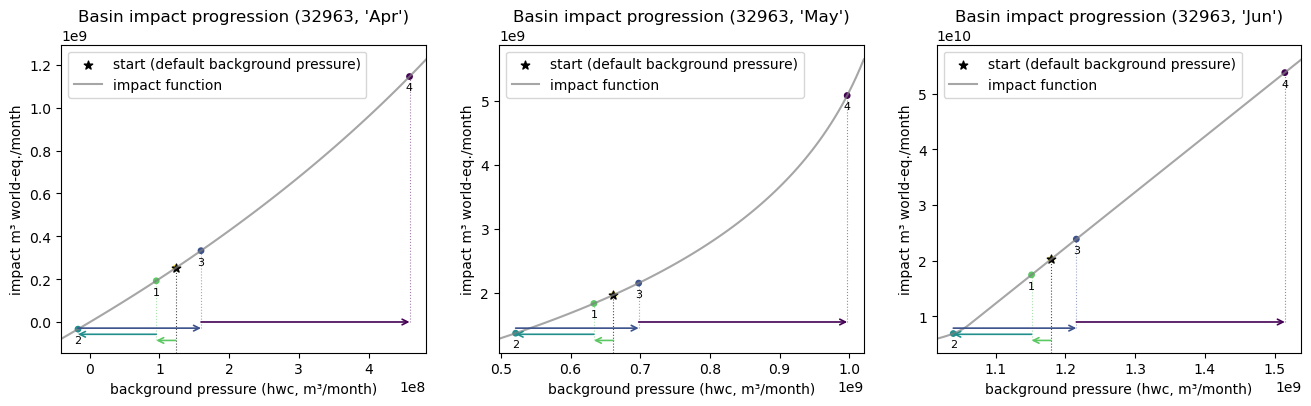

In [21]:
fig,ax = plt.subplots(figsize=[16,4], ncols=3)
BASIN_MEMORY.plot_impact_progress((int(ebro_basin[1:]),"Apr"), ax=ax[0], show=False)
BASIN_MEMORY.plot_impact_progress((int(ebro_basin[1:]),"May"), ax=ax[1], show=False)
BASIN_MEMORY.plot_impact_progress((int(ebro_basin[1:]),"Jun"), ax=ax[2], show=False)
plt.show()

In the BASIN_MEMORY, we have the impact progression saved as list. The last few positions are repeated (and therefore removed before plotting the figure above), since these are the final calls to the basin memory to update all the entries in the CF matrix of brightway.

In [22]:
BASIN_MEMORY.get_increm_cfs(int(ebro_basin[1:]))

{'Jan': [],
 'Feb': [],
 'Mar': [],
 'Apr': [2.1454875256112236,
  2.0342459000771473,
  2.2168091725333245,
  2.6596052278467566,
  2.6596052278467566,
  2.6596052278467566,
  2.6596052278467566,
  2.6596052278467566],
 'May': [4.7417645627809595,
  4.243944249479226,
  5.105558956623076,
  9.259638782364208,
  9.259638782364208,
  9.259638782364208,
  9.259638782364208,
  9.259638782364208],
 'Jun': [100.00000000000003,
  95.1466543642402,
  100.0,
  99.99999999999999,
  99.99999999999999,
  99.99999999999999,
  99.99999999999999,
  99.99999999999999],
 'Jul': [],
 'Aug': [],
 'Sep': [],
 'Oct': [],
 'Nov': [],
 'Dec': []}

Interestingly, the total water consumption in April moves into negative values for a short time. This because of two reasons:
 1. In reality, the water consumption of our process in April would arguably be lower than in June or July, but the Basin_memory distributed it equally to all months. 
 2. the order in which the flows appear in the LCIA calculation is arbitrary. In reality, withdrawals would happen before returning water (and thus moving left on the axis). 

## Set overall intervention level
In some cases, we would like to set the overall intervention level, e.g. when we want to assess how th product system would perform if the total water consumption in the watershed was lower.
We can achieve this with the the scale_initial_hwc() function, and subsequently changing a setting of our LCIA method.

In [23]:
ebro_basin_int = int(ebro_basin[1:])

# increase April water consumption by 40%
BASIN_MEMORY.reset()
print("old:", BASIN_MEMORY.get_current(ebro_basin_int, "Apr"))
BASIN_MEMORY.scale_initial_hwc(ebro_basin_int,"Apr",1.4)
print("new:", BASIN_MEMORY.get_current(ebro_basin_int, "Apr"))

old: 123489058.0
new: 172884681.2


In [24]:
BASIN_MEMORY

<BasinMemory
month-basin-combinations=112872
cf calculation iterations=0
number of touched MBCs=0>

In [25]:
# BASIN_MEMORY.reset() # just in case we already used it before, ensures that we start at the current background pressure 
LCA = EdgeLCIA(
    demand={ebro_wheat: 2e9}, # 2000000 tonnes of wheat grain
    method=('AWARE 2.0', 'incremental'),
    additional_topologies = {"fine_topology": basin_topologies},
    allowed_functions={"calculate_CF":calculate_CF, "BASIN_MEMORY": BASIN_MEMORY}
)

# setting method to assume that inventory is included in background situation (as last user)
LCA.method_metadata["inventory_feedback"]["included_in_background"] = True
LCA.lci()
LCA.apply_strategies()
LCA.evaluate_cfs()
LCA.lcia()
cf_df_2 = LCA.generate_cf_table()
LCA.score

Finding direct matches        [1/5]
Resolving aggregate locations [2/5]
Resolving dynamic locations   [3/5]
{'BR-RR': [], 'Europe without Austria': ['AD', 'AL', 'BA', 'BE', 'BG', 'BY', 'CH', 'CZ', 'DE', 'DK', 'EE', 'FI', 'FR', 'GB', 'GI', 'GR', 'HR', 'HU', 'IE', 'IM', 'IS', 'IT', 'JE', 'LI', 'LT', 'LU', 'LV', 'MC', 'MD', 'ME', 'MK', 'MT', 'NL', 'NO', 'PL', 'PT', 'RO', 'RS', 'SE', 'SI', 'SK', 'SM', 'UA'], 'SAS': ['AF', 'BD', 'BT', 'IN-AP', 'IN-AR', 'IN-AS', 'IN-BR', 'IN-CH', 'IN-CT', 'IN-DH', 'IN-DL', 'IN-GA', 'IN-GJ', 'IN-HP', 'IN-HR', 'IN-JH', 'IN-JK', 'IN-KA', 'IN-KL', 'IN-MH', 'IN-ML', 'IN-MN', 'IN-MP', 'IN-MZ', 'IN-NL', 'IN-OR', 'IN-PB', 'IN-PY', 'IN-RJ', 'IN-SK', 'IN-TN', 'IN-TR', 'IN-UP', 'IN-UT', 'IN-WB', 'IR', 'LK', 'NP', 'PK'], 'US-WECC': ['US-CA', 'US-CO', 'US-ID', 'US-OR', 'US-WA'], 'IN-WB': [], 'CH': [], 'CA-AB': [], 'US-OR': [], 'IN-JH': [], 'IN-GJ': [], 'MX': [], 'IN-RJ': [], 'CN-GD': [], 'QA': [], 'CN-SC': [], 'DO': [], 'US-MRO': ['US-IA', 'US-MN', 'US-ND'], 'IN-ML': [],

19556160068.74101

In [26]:
display(cf_df_2.loc[cf_df_2["consumer location"]==ebro_basin].iloc[:,relevant_cols])

print("CF is the average of:")
avg = 0
months=ebro_wheat.as_dict()["ConsumerSeason"].split("_")
for month in months:
    cf = BASIN_MEMORY.get_increm_cfs((ebro_basin_int,month))[-1]
    print(month,":",round(cf,3))
    avg +=cf
print("average :", round(avg/len(months),3))

,supplier categories,consumer name,consumer location,amount,CF,impact
8899,"(water, surface water)",wheat grain production,B32963,8.424091e+07,-18.774064,-1.581544e+09
8900,"(water, ground-)",wheat grain production,B32963,3.369636e+08,-18.774064,-6.326177e+09
8901,"(natural resource, in water)","irrigation, sprinkler",B32963,5.296659e+08,18.774064,9.943983e+09
8902,"(natural resource, in water)","irrigation, sprinkler",B32963,8.976622e+08,18.774064,1.685277e+10


CF is the average of:
Apr : 1.958
May : 3.633
Jun : 50.731
average : 18.774


removed last 4 positions
removed last 4 positions
removed last 4 positions


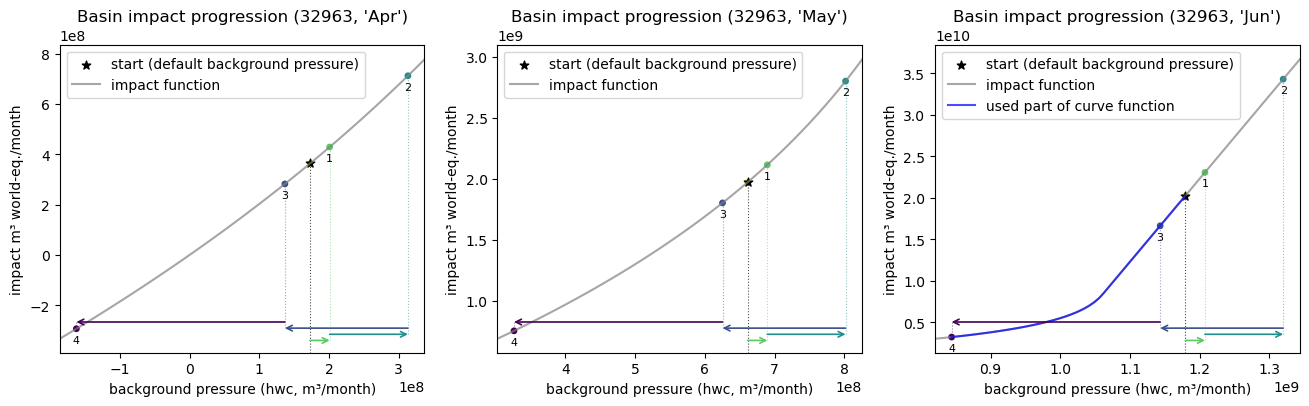

In [ ]:
fig,ax = plt.subplots(figsize=[16,4], ncols=3)
BASIN_MEMORY.plot_impact_progress((int(ebro_basin[1:]),"Apr"), ax=ax[0], show=False, plot_used_part=True)
BASIN_MEMORY.plot_impact_progress((int(ebro_basin[1:]),"May"), ax=ax[1], show=False, plot_used_part=True)
BASIN_MEMORY.plot_impact_progress((int(ebro_basin[1:]),"Jun"), ax=ax[2], show=False, plot_used_part=True)
plt.show()